In [1]:
!pip install tensorflow
!pip install tensorflow-hub
!pip install opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.4/572.4 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 61.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 64.5 MB/s eta 0:00:00
  Attempting uninstall: keras
    Found existing installation: keras 3.8.0
    Uninstalling keras-3.8.0:
      Successfully uninstalled keras-3.8.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 41.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 19.4 MB/s eta 0:00:00


In [2]:
import numpy as np
import cv2

import PIL.Image as Image
import os

import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_hub as hub

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

In [4]:
import tf_keras
IMAGE_SHAPE = (224,224)
classififer = tf_keras.Sequential([
    hub.KerasLayer("https://tfhub.dev/google/tf2-preview/mobilenet_v2/classification/4",input_shape =IMAGE_SHAPE+(3,))
])

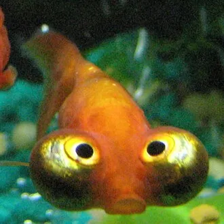

In [5]:
img = Image.open('/content/glod_fish.webp').resize(IMAGE_SHAPE)
img

In [6]:
img = np.array(img)/255.0
img.shape

(224, 224, 3)

In [7]:
img[np.newaxis].shape

(1, 224, 224, 3)

In [8]:
result = classififer.predict(img[np.newaxis])

1/1 [==============================] - 0s 330ms/step


In [9]:
result.shape

(1, 1001)

In [10]:
predicted_index = np.argmax(result)
predicted_index

np.int64(2)

In [11]:
with open('/content/imagenet_label.txt','r') as f:
   image_label = f.read().splitlines()

In [12]:
image_label[:5]

['background', 'tench', 'goldfish', 'great white shark', 'tiger shark']

In [13]:
image_label[predicted_index]

'goldfish'

In [14]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url,cache_dir='.',untar=True)

228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [15]:
data_dir

'./datasets/flower_photos'

In [16]:
import pathlib
data_dir = pathlib.Path(data_dir) / 'flower_photos'
data_dir

PosixPath('datasets/flower_photos/flower_photos')

In [17]:
list(data_dir.glob('*/*.jpg'))[:5]

[PosixPath('datasets/flower_photos/flower_photos/dandelion/4634716478_1cbcbee7ca.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/dandelion/8267315764_129f2e1d77_m.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/dandelion/6983120596_8b9f084ac2_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/dandelion/1776290427_9d8d5be6ac.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/dandelion/5607256228_2294c201b3.jpg')]

In [18]:
roses = list(data_dir.glob('roses/*'))
roses[:5]

[PosixPath('datasets/flower_photos/flower_photos/roses/15537825851_a80b6321d7_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/15184419268_7230e9728e.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/5602220566_5cdde8fa6c_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/9298314004_c1a8146521.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/15602874619_03fd934bed.jpg')]

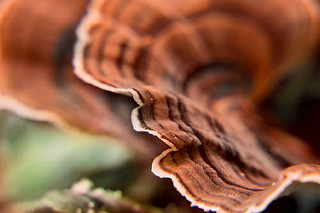

In [19]:
Image.open(roses[0])

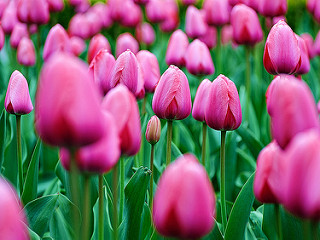

In [20]:
tulips = list(data_dir.glob('tulips/*'))
Image.open(tulips[1])

In [21]:
flowers_image_dict = {
    'roses':list(data_dir.glob('roses/*')),
    'daisy':list(data_dir.glob('daisy/*')),
    'dandelion':list(data_dir.glob('dandelion/*')),
    'sunflowers':list(data_dir.glob('sunflowers/*')),
    'tulips':list(data_dir.glob('tulips/*')),
}

In [22]:
flowers_image_dict['roses']

[PosixPath('datasets/flower_photos/flower_photos/roses/15537825851_a80b6321d7_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/15184419268_7230e9728e.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/5602220566_5cdde8fa6c_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/9298314004_c1a8146521.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/15602874619_03fd934bed.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/15032112248_30c5284e54_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/3072908271_08764c732a_m.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/3500121696_5b6a69effb_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/6069602140_866eecf7c2_m.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/99383371_37a5ac12a3_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/6473543547_4fefdbd5dc.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/90927

In [23]:
flowers_image_labels = {
    'roses':0,
    'daisy':1,
    'dandelion':2,
    'sunflowers':3,
    'tulips':4,
}

In [24]:
str(flowers_image_dict['roses'][0])
img = cv2.imread(str(flowers_image_dict['roses'][0]))
img.shape

(213, 320, 3)

In [25]:
x,y = [],[]

for flower_name,images in flowers_image_dict.items():
  for image in images:
    img = cv2.imread(str(image))
    resized_img = cv2.resize(img,(224,224))
    x.append(resized_img)
    y.append(flowers_image_labels[flower_name])

array([[[112, 135, 202],
        [111, 138, 213],
        [118, 148, 227],
        ...,
        [ 67,  91, 150],
        [ 60,  79, 128],
        [ 56,  61, 105]],

       [[112, 138, 206],
        [111, 140, 217],
        [118, 148, 229],
        ...,
        [ 70,  97, 154],
        [ 66,  85, 135],
        [ 61,  67, 115]],

       [[112, 142, 213],
        [111, 144, 224],
        [116, 150, 233],
        ...,
        [ 73,  99, 159],
        [ 69,  89, 142],
        [ 65,  73, 123]],

       ...,

       [[ 57,  77, 136],
        [ 61,  84, 142],
        [ 63,  91, 151],
        ...,
        [  4,   4,  10],
        [  1,   1,   8],
        [  1,   0,   9]],

       [[ 61,  80, 143],
        [ 63,  86, 148],
        [ 64,  92, 153],
        ...,
        [  4,   3,  12],
        [  2,   1,  10],
        [  1,   0,  10]],

       [[ 63,  83, 148],
        [ 64,  87, 152],
        [ 64,  92, 156],
        ...,
        [  4,   3,  12],
        [  2,   1,  11],
        [  2,   0,  12]]], dtype=uint8)
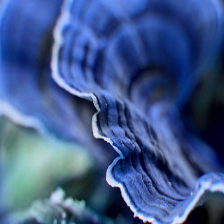

In [26]:
x[0]

In [27]:
y[0]

0

In [28]:
x = np.array(x)
y = np.array(y)

X = x/255

In [29]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(X,y,random_state=0)

In [30]:
x_train[0]

array([[[0.60784314, 0.64313725, 0.61176471],
        [0.65490196, 0.68235294, 0.66666667],
        [0.67058824, 0.71764706, 0.71764706],
        ...,
        [0.72941176, 0.70588235, 0.64313725],
        [0.59215686, 0.61176471, 0.5372549 ],
        [0.58039216, 0.61568627, 0.56078431]],

       [[0.59215686, 0.63529412, 0.58431373],
        [0.62352941, 0.65882353, 0.62352941],
        [0.63529412, 0.6745098 , 0.6627451 ],
        ...,
        [0.7372549 , 0.7372549 , 0.65882353],
        [0.72156863, 0.70588235, 0.63529412],
        [0.69411765, 0.70196078, 0.6627451 ]],

       [[0.59215686, 0.63921569, 0.57254902],
        [0.60784314, 0.63921569, 0.59607843],
        [0.64705882, 0.6745098 , 0.65490196],
        ...,
        [0.7372549 , 0.74509804, 0.70196078],
        [0.87058824, 0.81960784, 0.77647059],
        [0.71372549, 0.70980392, 0.67058824]],

       ...,

       [[0.2627451 , 0.37647059, 0.29411765],
        [0.23529412, 0.37254902, 0.29411765],
        [0.25882353, 0

In [31]:
initial_pred = classififer.predict(np.array([x_train[0],x_train[1],x_train[2]]))
initial_pred

1/1 [==============================] - 0s 35ms/step


array([[ 0.24147609,  0.6294491 ,  0.6528717 , ..., -0.3615662 ,
        -0.13645583, -1.2221377 ],
       [ 0.36055294, -1.8950086 , -0.3418429 , ...,  0.41295785,
        -0.48052672,  1.1785629 ],
       [ 0.15933862, -1.5798297 , -0.8510936 , ..., -0.03201679,
        -0.48527828, -0.8519622 ]], dtype=float32)

In [32]:
initial_pred = np.argmax(initial_pred,axis=1)
initial_pred

array([329, 288, 986])

array([[[112, 135, 202],
        [111, 138, 213],
        [118, 148, 227],
        ...,
        [ 67,  91, 150],
        [ 60,  79, 128],
        [ 56,  61, 105]],

       [[112, 138, 206],
        [111, 140, 217],
        [118, 148, 229],
        ...,
        [ 70,  97, 154],
        [ 66,  85, 135],
        [ 61,  67, 115]],

       [[112, 142, 213],
        [111, 144, 224],
        [116, 150, 233],
        ...,
        [ 73,  99, 159],
        [ 69,  89, 142],
        [ 65,  73, 123]],

       ...,

       [[ 57,  77, 136],
        [ 61,  84, 142],
        [ 63,  91, 151],
        ...,
        [  4,   4,  10],
        [  1,   1,   8],
        [  1,   0,   9]],

       [[ 61,  80, 143],
        [ 63,  86, 148],
        [ 64,  92, 153],
        ...,
        [  4,   3,  12],
        [  2,   1,  10],
        [  1,   0,  10]],

       [[ 63,  83, 148],
        [ 64,  87, 152],
        [ 64,  92, 156],
        ...,
        [  4,   3,  12],
        [  2,   1,  11],
        [  2,   0,  12]]], dtype=uint8)
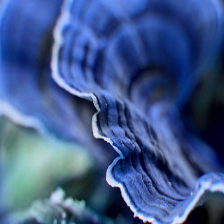

In [33]:
x[0]

array([[[245, 237, 230],
        [246, 239, 230],
        [247, 241, 230],
        ...,
        [240, 228, 217],
        [231, 219, 201],
        [214, 204, 183]],

       [[245, 238, 230],
        [246, 239, 230],
        [247, 240, 231],
        ...,
        [239, 228, 219],
        [232, 219, 201],
        [215, 204, 183]],

       [[246, 238, 231],
        [246, 238, 231],
        [247, 240, 231],
        ...,
        [240, 229, 221],
        [233, 221, 203],
        [217, 205, 185]],

       ...,

       [[249, 241, 241],
        [249, 243, 238],
        [250, 243, 240],
        ...,
        [240, 232, 219],
        [240, 232, 219],
        [240, 232, 220]],

       [[248, 242, 240],
        [251, 243, 239],
        [250, 243, 240],
        ...,
        [240, 233, 218],
        [239, 233, 218],
        [240, 232, 219]],

       [[247, 242, 241],
        [252, 243, 240],
        [250, 243, 242],
        ...,
        [240, 233, 218],
        [238, 233, 217],
        [240, 232, 219]]], dtype=uint8)
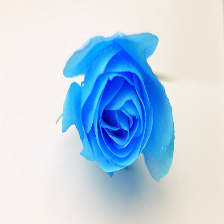

In [34]:
x[1]

array([[[22, 25, 18],
        [24, 27, 17],
        [23, 27, 16],
        ...,
        [44, 47, 32],
        [46, 49, 32],
        [48, 52, 33]],

       [[26, 24, 18],
        [28, 27, 18],
        [25, 27, 17],
        ...,
        [43, 45, 33],
        [47, 47, 32],
        [49, 50, 34]],

       [[26, 23, 16],
        [29, 27, 17],
        [28, 27, 17],
        ...,
        [43, 42, 32],
        [46, 44, 33],
        [48, 46, 35]],

       ...,

       [[21, 25, 20],
        [21, 26, 21],
        [18, 24, 19],
        ...,
        [28, 67, 76],
        [33, 68, 80],
        [27, 61, 75]],

       [[23, 27, 22],
        [23, 28, 23],
        [19, 26, 21],
        ...,
        [24, 63, 71],
        [30, 62, 72],
        [27, 61, 73]],

       [[26, 28, 26],
        [22, 28, 26],
        [17, 28, 25],
        ...,
        [20, 61, 64],
        [26, 54, 61],
        [25, 59, 67]]], dtype=uint8)
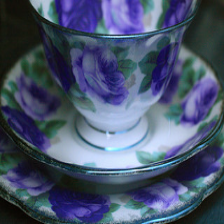

In [35]:
x[2]

In [38]:
image_label[329]

'sea urchin'

In [39]:
image_label[288]

'lynx'

In [40]:
image_label[986]

'daisy'

In [41]:
new_model = tf_keras.Sequential([
    hub.KerasLayer("https://tfhub.dev/google/tf2-preview/mobilenet_v2/feature_vector/4",input_shape =IMAGE_SHAPE+(3,),trainable=False),
    tf_keras.layers.Dense(5,activation='softmax')
])

In [42]:
new_model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 keras_layer_1 (KerasLayer)  (None, 1280)              2257984   
                                                                 
 dense (Dense)               (None, 5)                 6405      
                                                                 
Total params: 2264389 (8.64 MB)
Trainable params: 6405 (25.02 KB)
Non-trainable params: 2257984 (8.61 MB)
_________________________________________________________________


In [43]:
new_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [44]:
new_model.fit(x_train,y_train,epochs=5,validation_data=(x_test,y_test))

Epoch 1/5
86/86 [==============================] - 52s 578ms/step - loss: 0.8228 - accuracy: 0.6864 - val_loss: 0.5424 - val_accuracy: 0.8224
Epoch 2/5
86/86 [==============================] - 48s 563ms/step - loss: 0.4124 - accuracy: 0.8576 - val_loss: 0.4444 - val_accuracy: 0.8475
Epoch 3/5
86/86 [==============================] - 48s 560ms/step - loss: 0.3261 - accuracy: 0.8939 - val_loss: 0.3895 - val_accuracy: 0.8617
Epoch 4/5
86/86 [==============================] - 48s 560ms/step - loss: 0.2659 - accuracy: 0.9175 - val_loss: 0.3864 - val_accuracy: 0.8671
Epoch 5/5
86/86 [==============================] - 49s 569ms/step - loss: 0.2282 - accuracy: 0.9320 - val_loss: 0.3780 - val_accuracy: 0.8671


In [45]:
new_model.evaluate(x_test,y_test)

29/29 [==============================] - 13s 432ms/step - loss: 0.3780 - accuracy: 0.8671


[0.37803858518600464, 0.8671023845672607]

Thats the power of MobileNet